<a href="https://colab.research.google.com/github/HongYeonLee/Artificial-Intelligence/blob/main/HW2_2371049.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part A. Understanding ResNet by Hand

#### A1 Residual Forward & Backward by Hand


주어진 식: $y = F(x) + x$, 여기서 $F(x) = W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2$

<br> 1단계: $z_1 = W_1 \cdot x + b_1$ 계산

$$z_1 = \begin{bmatrix} 0.5 & -0.2 \\ -0.3 & 0.4 \end{bmatrix} \cdot \begin{bmatrix} 1.0 \\ -0.5 \end{bmatrix} + \begin{bmatrix} 0.0 \\ 0.1 \end{bmatrix}$$

- 상단 원소: $(0.5 \times 1.0) + (-0.2 \times -0.5) + 0.0 = 0.5 + 0.1 + 0.0 = 0.6$
- 하단 원소: $(-0.3 \times 1.0) + (0.4 \times -0.5) + 0.1 = -0.3 - 0.2 + 0.1 = -0.4$
- 결과: $z_1 = [0.6, -0.4]$

<br> 2단계: $h_1 = \text{ReLU}(z_1)$

- $h_1 = [\max(0, 0.6), \max(0, -0.4)] = [0.6, 0.0]$

- 결과: $h_1 = [0.6, 0.0]$

<br> 3단계: $F(x) = W_2 \cdot h_1 + b_2$

$$F(x) = \begin{bmatrix} 0.6 & 0.1 \\ 0.2 & -0.5 \end{bmatrix} \cdot \begin{bmatrix} 0.6 \\ 0.0 \end{bmatrix} + \begin{bmatrix} 0.0 \\ 0.0 \end{bmatrix}$$

- 상단: $(0.6 \times 0.6) + (0.1 \times 0.0) = 0.36$
- 하단: $(0.2 \times 0.6) + (-0.5 \times 0.0) = 0.12$
- 결과: $F(x) = [0.36, 0.12]$

<br> 4단계: $y = F(x) + x$
$$y = [0.36, 0.12] + [1.0, -0.5] = [1.36, -0.38]$$
- 결과: $y = [1.36, -0.38]$

Loss Gradient: $\frac{\partial L}{\partial y}$
<br> Loss function이 $L = 0.5 \cdot \|y - t\|^2$ 이므로 $$\frac{\partial L}{\partial y} = y - t$$
- $y = [1.36, -0.38], t = [0.3, 0.0]$
- $\frac{\partial L}{\partial y} = [1.06, -0.38]$

<br> (1) $\frac{\partial L}{\partial F}$ 유도

$$\frac{\partial L}{\partial F} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial F}$$

<br> 위 식 $y = F + x$를 $F$에 대해 미분하면 $\frac{\partial y}{\partial F} = 1$ (단위 행렬 $I$)이므로$$\frac{\partial L}{\partial F} = \frac{\partial L}{\partial y} \cdot 1 = \frac{\partial L}{\partial y}$$

<br><br> (2) $\frac{\partial L}{\partial x_{skip}}$ 유도
$$\frac{\partial L}{\partial x_{skip}} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x}$$

<br> 마찬가지로 $y = F + x$를 $x$에 대해 미분하면 $\frac{\partial y}{\partial x} = 1$ (단위 행렬 $I$)이므로 <br><br> $$\frac{\partial L}{\partial x_{skip}} = \frac{\partial L}{\partial y} \cdot 1 = \frac{\partial L}{\partial y}$$

따라서
<br>
$$\frac{\partial y}{\partial x} = \frac{\partial}{\partial x}(F(x) + x) = \frac{\partial F}{\partial x} + 1$$
<br>
$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial F}{\partial x} + \frac{\partial L}{\partial y} \cdot 1$$

<br><br>
여기서 $\frac{\partial L}{\partial y} \cdot 1$이 바로 skip 경로를 통해 흐르는 gradient $\frac{\partial L}{\partial x_{skip}}$이며, 결과적으로 $\frac{\partial L}{\partial y}$와 동일해진다

Backpropagation 관점에서 덧셈 노드는 상류에서 전달된 gradient를 하류의 모든 입력 분기로 그대로 복사하여 전달하는 성질을 가진다.
왜냐하면 출력 y가 각 입력(F와 x)의 단순 합으로 정의되기 때문이다. 변수 x가 미세하게 $\Delta x$만큼 변할 때, 결과값 $y$도 동일하게 $\Delta x$만큼 변하므로 변화율(Local Gradient)이 $1$이 되기 때문이다.
<br>
강의자료 8장 26페이지에서 가중치 층(CONV layers)을 통과하는 경로는 복잡한 연산을 거치며 기울기가 작아질 수 있지만, Skip 경로(Identity x)는 출력 $y$와 직접적으로 덧셈으로 연결되어 있다. 이 덕분에 상류의 오차 신호($\frac{\partial L}{\partial y}$)가 flow unchanged로 전달된다

(1) Plain 버전 $y_{plain} = F(x)$
<br> Plain 버전에서는 출력이 오직 가중치 층($F$)을 통해서만 전달

<br> $y = F$ 이므로 $\frac{\partial L}{\partial F} = \frac{\partial L}{\partial y} = [1.06, -0.38]$

<br> $F = W_2 \cdot h_1 + b_2$ 이므로
- $\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial F} \cdot \frac{\partial F}{\partial W_2} = \frac{\partial L}{\partial F} \cdot h_1^T$
- $\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial F} \cdot \frac{\partial F}{\partial b_2} = \frac{\partial L}{\partial F}$

<br> $\frac{\partial L}{\partial h_1} = W_2^T \cdot \frac{\partial L}{\partial F}$

<br>
$\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial h_1} \cdot \text{ReLU}'(z_1)$

<br><br>
$z_1 = W_1 \cdot x + b_1$ 이므로
$$\frac{\partial L}{\partial x}_{plain} = W_1^T \cdot \frac{\partial L}{\partial z_1}$$

(2) Residual 버전 $y = F(x) + x$으로 위에서 구한 것처럼 Skip connection 추가된다.
$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial F}{\partial x} + \frac{\partial L}{\partial y} \cdot 1 = \frac{\partial L}{\partial x}_{plain} + \frac{\partial L}{\partial x_{skip}}$$



plain 버전은 gradient가 곱셈 연산으로만 전달되기에 층이 깊어질 수록 1이하의 값을 계속 곱하면서 gradient가 소실될 수 있다. 그러나 Residual버전은 gradient가 0이 되어도 뒤의 항 $\frac{\partial L}{\partial y}$이 남기에 소실 문제 해결

#### A2. Parameter & FLOP Countingd

1.학습 가능한 파라미터 수 <br>
(i). Convolution 레이어 (2개):
- 하나의 Conv 레이어 파라미터 = $K \times K \times C_{in} \times C_{out}$ (Bias 없음)
- 계산: $3 \times 3 \times 16 \times 16 = 2,304$
- 2개의 레이어이므로: $2,304 \times 2 = 4,608$개

(ii). Batch Normalization 레이어 (2개):
- BN은 채널당 $\gamma$(Scale)와 $\beta$(Shift) 파라미터를 가지므로
- 하나의 BN 레이어 파라미터 = $2 \times C_{out}$
- 계산: $2 \times 16 = 32$
- 2개의 레이어이므로: $32 \times 2 = 64$개
- 총합: $4,608 + 64 = 4,672$개

---
2.MACs <br>
공식: $K \times K \times C_{in} \times H_{out} \times W_{out} \times C_{out}$ <br>
계산:
- 하나의 Conv 레이어: $3 \times 3 \times 16 \times 32 \times 32 \times 16 = 2,359,296$
- 2개의 레이어이므로: $2,359,296 \times 2 =4,718,592 $ MACs

---
3.Downsampling block <br>
(i) 학습 가능한 파라미터 수
1. Main Path (Conv 2개):
- Conv 1: $3 \times 3 \times 16 \times 32 = 4,608$
- Conv 2: $3 \times 3 \times 32 \times 32 = 9,216$
2. Skip Path (1x1 Conv 1개):
- $1 \times 1 \times 16 \times 32 = 512$
3. BN 레이어 (3개 - Main 2개, Skip 1개):
- 각 BN은 출력 채널 수에 비례: $(2 \times 32) + (2 \times 32) + (2 \times 32) = 192$
4. 총합: $4,608 + 9,216 + 512 + 192 = 14,528$개 <br>

(ii) MACs
1. Conv 1 ($3 \times 3, stride=2$):
- $3 \times 3 \times 16 \times (32/2) \times (32/2) \times 32 = 1,179,648$
2. Conv 2 ($3 \times 3, stride=1$):
- $3 \times 3 \times 32 \times 16 \times 16 \times 32 = 2,359,296$
3. Skip Path ($1 \times 1, stride=2$):
- $1 \times 1 \times 16 \times 16 \times 16 \times 32 = 131,072$
4. 총합: $1,179,648 + 2,359,296 + 131,072 = 3,670,016$ MACs

(iii) 1×1 projection 필요 이유 <br>
이전 블록은 입력과 출력의 크기가 같았지만, 이번 블록은 입력의 채널 수(16)와 크기(W x H, 32 x 32)가 출력(32, 16 x 16)과 다르기 때문에 skip connection에서 덧셈 연산을 수행할 수 있도록 차원(dimension)을 일치시키기 위해 $1 \times 1$ projection이 필요하다


#### A3. BatchNorm Forward by Hand

입력 $X = \begin{bmatrix} 2.0 & 1.0 \\ 4.0 & 3.0 \\ 0.0 & -1.0 \\ -2.0 & 1.0 \end{bmatrix}$ (4개 샘플, 2개 feature) <br><br>
파라미터: $\gamma = [1.5, 0.5]$, $\beta = [0.0, -1.0]$ <br> <br>
상수: $\epsilon = 1e-5$

----
feature별 평균($\mu$)과 분산($\sigma^2$) 계산 - 각 열(column)에 대해 독립적으로 계산 <br>

Feature 1 (첫 번째 열):<br>
$\mu_1 = \frac{2.0 + 4.0 + 0.0 + (-2.0)}{4} = \frac{4.0}{4} = {1.0}$ <br>
$\sigma^2_1 = \frac{(2-1)^2 + (4-1)^2 + (0-1)^2 + (-2-1)^2}{4} = \frac{1 + 9 + 1 + 9}{4} = \frac{20}{4} = {5.0}$ <br><br>
Feature 2 (두 번째 열): <br>
$\mu_2 = \frac{1.0 + 3.0 + (-1.0) + 1.0}{4} = \frac{4.0}{4} = {1.0}$<br>
$\sigma^2_2 = \frac{(1-1)^2 + (3-1)^2 + (-1-1)^2 + (1-1)^2}{4} = \frac{0 + 4 + 4 + 0}{4} = \frac{8}{4} = {2.0}$


---
공식: $\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$ <br>
Feature 1 정규화 ($\sqrt{5 + 1e-5} \approx 2.236$):<br>
- $\hat{x}_{1,1} = (2.0 - 1.0) / 2.236 \approx {0.447}$
- $\hat{x}_{2,1} = (4.0 - 1.0) / 2.236 \approx {1.342}$
- $\hat{x}_{3,1} = (0.0 - 1.0) / 2.236 \approx {-0.447}$
- $\hat{x}_{4,1} = (-2.0 - 1.0) / 2.236 \approx {-1.342}$ <br>
<br> Feature 2 정규화 ($\sqrt{2 + 1e-5} \approx 1.414$):<br>
- $\hat{x}_{1,2} = (1.0 - 1.0) / 1.414 = {0.0}$
- $\hat{x}_{2,2} = (3.0 - 1.0) / 1.414 \approx {1.414}$
- $\hat{x}_{3,2} = (-1.0 - 1.0) / 1.414 \approx {-1.414}$
- $\hat{x}_{4,2} = (1.0 - 1.0) / 1.414 = {0.0}$ <br>

---
공식: $y_i = \gamma \hat{x}_i + \beta$ <br><br>
Feature 1 ($y_1 = 1.5 \hat{x}_1 + 0.0$): <br>
- $[0.671, 2.013, -0.671, -2.013]$ <br>

<br> Feature 2 ($y_2 = 0.5 \hat{x}_2 - 1.0$): <br>
- $y_{1,2} = 0.5(0.0) - 1.0 = {-1.0}$
- $y_{2,2} = 0.5(1.414) - 1.0 \approx {-0.293}$
- $y_{3,2} = 0.5(-1.414) - 1.0 \approx {-1.707}$
- $y_{4,2} = 0.5(0.0) - 1.0 = {-1.0}$ <br>

최종 $y$ 행렬:<br>
$$y = \begin{bmatrix} 0.671 & -1.0 \\ 2.013 & -0.293 \\ -0.671 & -1.707 \\ -2.013 & -1.0 \end{bmatrix}$$


evaluation 시에는 현재 배치의 통계량 대신 학습 단계에서 미리 계산하여 저장해 둔 Running Mean과 Running Variance을 고정하여 사용함으로써 배치 크기에 상관없이 Deterministic인 출력을 보장한다. 이는 개별 샘플을 추론할 때 결과가 배치 구성에 따라 변하는 것을 방지하고 학습 시 파악한 전체 데이터의 분포를 일관되게 반영하기 위해 필수적이다

---
## Part B. Implementing & Training ResNet-20



#### B1. ResNet-20 from Scratch

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random
import numpy as np

# 1. 시드 고정 (재현성)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 2. 모델 정의 (He et al. Specification)
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

class BasicBlock(nn.Module):
    def __init__(self, inplanes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Identity()
        if stride != 1 or inplanes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)

class ResNet20(nn.Module):
    def __init__(self):
        super(ResNet20, self).__init__()
        self.inplanes = 16
        # Stem: 3x3 conv, 16 channels
        self.conv1 = conv3x3(3, 16)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        # Three stages, n=3 blocks each
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, 10)

    def _make_layer(self, planes, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.inplanes, planes, stride))
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [13]:
# 3. 데이터 로더 (No Augmentation 설정)
def get_b1_dataloaders(batch_size=128):
    stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    # 과제 요구사항: No Augmentation
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader

Total Parameter Count: 0.272474M
Epoch [1/40] Train Loss: 1.5896 | Test Loss: 1.7858 | Test Acc: 39.96%
Epoch [2/40] Train Loss: 1.0854 | Test Loss: 1.1122 | Test Acc: 61.42%
Epoch [3/40] Train Loss: 0.8488 | Test Loss: 1.0271 | Test Acc: 65.68%
Epoch [4/40] Train Loss: 0.7044 | Test Loss: 0.8920 | Test Acc: 68.00%
Epoch [5/40] Train Loss: 0.5945 | Test Loss: 0.6527 | Test Acc: 77.75%
Epoch [6/40] Train Loss: 0.5128 | Test Loss: 0.7102 | Test Acc: 76.20%
Epoch [7/40] Train Loss: 0.4511 | Test Loss: 0.6756 | Test Acc: 77.39%
Epoch [8/40] Train Loss: 0.3998 | Test Loss: 0.6665 | Test Acc: 78.47%
Epoch [9/40] Train Loss: 0.3467 | Test Loss: 0.6804 | Test Acc: 78.28%
Epoch [10/40] Train Loss: 0.3037 | Test Loss: 0.6442 | Test Acc: 80.28%
Epoch [11/40] Train Loss: 0.2641 | Test Loss: 0.6227 | Test Acc: 81.07%
Epoch [12/40] Train Loss: 0.2219 | Test Loss: 0.6514 | Test Acc: 81.04%
Epoch [13/40] Train Loss: 0.1945 | Test Loss: 0.7283 | Test Acc: 80.16%
Epoch [14/40] Train Loss: 0.1609 | Test 

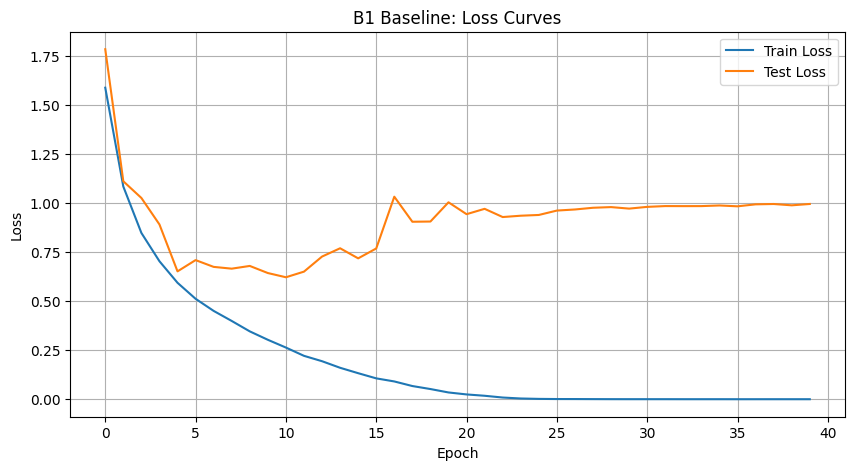

In [16]:
# 4. 학습 함수 (40 Epochs, Cosine Annealing)
def train_b1_baseline():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = ResNet20().to(device)

    # 파라미터 수 확인 (약 0.27M 확인용)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameter Count: {total_params / 1e6:.6f}M")

    trainloader, testloader = get_b1_dataloaders()

    # 과제 설정: SGD(momentum 0.9), LR 0.1, Weight Decay 0
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0)

    # 과제 설정: Cosine Learning Rate Schedule (40 epochs)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

    train_losses, test_losses, test_accs = [], [], []

    for epoch in range(40):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Test Loss 및 Accuracy 계산
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_train_loss = running_loss / len(trainloader)
        avg_test_loss = test_loss / len(testloader)
        acc = 100. * correct / total

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        test_accs.append(acc)

        scheduler.step()
        print(f"Epoch [{epoch+1}/40] Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Acc: {acc:.2f}%")

    # 결과 리포트 및 그래프
    print(f"\nFinal Test Accuracy: {test_accs[-1]:.2f}%")
    plot_results(train_losses, test_losses)

def plot_results(train_losses, test_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.title('B1 Baseline: Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# 실행
train_b1_baseline()

#### B2. Plain CNN vs ResNe

ResNet-20 Parameters: 272,474
PlainNet-20 Parameters: 269,722

[ResNet-20] Training Started on cuda...
Epoch [10/40] Train Loss: 0.2714 (90.36%) | Test Loss: 0.7356 (77.54%)
Epoch [20/40] Train Loss: 0.0279 (99.10%) | Test Loss: 0.9459 (82.31%)
Epoch [30/40] Train Loss: 0.0007 (100.00%) | Test Loss: 1.0394 (83.09%)
Epoch [40/40] Train Loss: 0.0005 (100.00%) | Test Loss: 1.0587 (83.00%)

[PlainNet-20] Training Started on cuda...
Epoch [10/40] Train Loss: 0.4403 (84.53%) | Test Loss: 0.7118 (76.84%)
Epoch [20/40] Train Loss: 0.1200 (95.76%) | Test Loss: 0.9359 (78.53%)
Epoch [30/40] Train Loss: 0.0025 (99.99%) | Test Loss: 1.0631 (82.45%)
Epoch [40/40] Train Loss: 0.0015 (99.99%) | Test Loss: 1.0952 (82.27%)

FINAL RESULTS (After 40 Epochs)
[ResNet-20]   Train Acc: 100.00% | Test Acc: 83.00%
[PlainNet-20] Train Acc: 99.99% | Test Acc: 82.27%


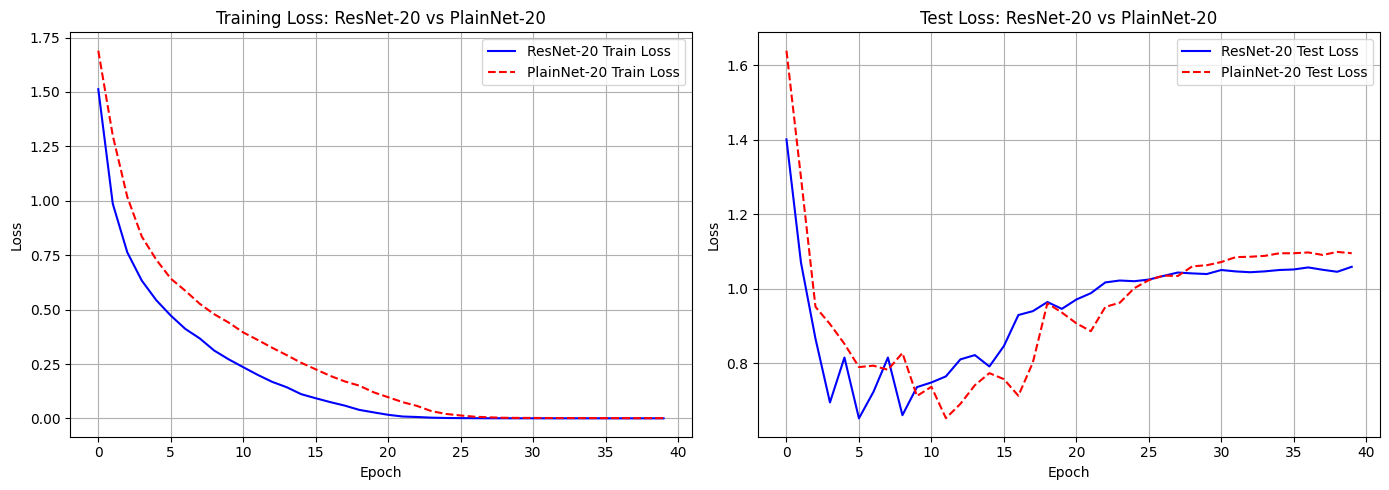

In [19]:
# 1. 시드 고정
set_seed(42)

# ==========================================
# [모델 정의] PlainNet-20 (Skip connection 제거)
# ==========================================
class PlainBlock(nn.Module):
    def __init__(self, inplanes, planes, stride=1):
        super(PlainBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)

        # PlainNet은 shortcut 연산이 없음

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # out += identity 구문 삭제
        return self.relu(out)

class PlainNet20(ResNet20):
    def __init__(self):
        super(PlainNet20, self).__init__()
        self.inplanes = 16
        self.conv1 = conv3x3(3, 16)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        # BasicBlock 대신 PlainBlock 사용
        self.layer1 = self._make_layer(PlainBlock, 16, 3, stride=1)
        self.layer2 = self._make_layer(PlainBlock, 32, 3, stride=2)
        self.layer3 = self._make_layer(PlainBlock, 64, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, 10)

# 공통 학습 함수
def train_and_evaluate(model, name, trainloader, testloader, epochs=40):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    print(f"\n[{name}] Training Started on {device}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        train_acc = 100. * correct_train / total_train
        avg_train_loss = running_loss / len(trainloader)

        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total_test += labels.size(0)
                correct_test += predicted.eq(labels).sum().item()

        test_acc = 100. * correct_test / total_test
        avg_test_loss = test_loss / len(testloader)

        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        scheduler.step()

        # 10 에폭 단위로만 출력하여 로그 간소화 (최종 에폭은 무조건 출력)
        if (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} ({train_acc:.2f}%) | Test Loss: {avg_test_loss:.4f} ({test_acc:.2f}%)")

    return history

# 5. 실험 실행 및 시각화
def run_b2_experiment():
    trainloader, testloader = get_b1_dataloaders()

    # 두 모델 초기화 및 파라미터 체크
    resnet = ResNet20()
    plainnet = PlainNet20()

    print(f"ResNet-20 Parameters: {sum(p.numel() for p in resnet.parameters()):,}")
    print(f"PlainNet-20 Parameters: {sum(p.numel() for p in plainnet.parameters()):,}")

    # 학습
    hist_resnet = train_and_evaluate(resnet, "ResNet-20", trainloader, testloader)
    hist_plain = train_and_evaluate(plainnet, "PlainNet-20", trainloader, testloader)

    # 리포팅
    print("\n" + "="*40)
    print("FINAL RESULTS (After 40 Epochs)")
    print("="*40)
    print(f"[ResNet-20]   Train Acc: {hist_resnet['train_acc'][-1]:.2f}% | Test Acc: {hist_resnet['test_acc'][-1]:.2f}%")
    print(f"[PlainNet-20] Train Acc: {hist_plain['train_acc'][-1]:.2f}% | Test Acc: {hist_plain['test_acc'][-1]:.2f}%")

    # 시각화 (Overlay Plots)
    plt.figure(figsize=(14, 5))

    # 1. Training Loss Overlay
    plt.subplot(1, 2, 1)
    plt.plot(hist_resnet['train_loss'], label='ResNet-20 Train Loss', color='blue')
    plt.plot(hist_plain['train_loss'], label='PlainNet-20 Train Loss', color='red', linestyle='--')
    plt.title('Training Loss: ResNet-20 vs PlainNet-20')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Test Loss Overlay
    plt.subplot(1, 2, 2)
    plt.plot(hist_resnet['test_loss'], label='ResNet-20 Test Loss', color='blue')
    plt.plot(hist_plain['test_loss'], label='PlainNet-20 Test Loss', color='red', linestyle='--')
    plt.title('Test Loss: ResNet-20 vs PlainNet-20')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 실행
run_b2_experiment()

분석<br>
같은 층(20)에서 두 모델은 비슷하게 학습된다. 각각 Train과 Test에서 PlainNet이 ResNet보다 아주 약간 더 나쁜 성능을 보이나 거의 비슷하다. ResNet 논문에서 보고된 문제는 층이 깊어질수록 모델의 표현력(Representation Power)은 커져야 함에도 불구하고, 실제로는 깊은 Plain 모델이 더 얕은 모델보다 훈련 오차(Training Error)와 테스트 오차(Test Error)가 모두 높게 나타나는 문제(degradation 문제)였다. 이는 과적합(Overfitting) 때문이 아니라, 층이 깊어짐에 따라 최적화(Optimization)가 어려워지기 때문에 발생한 것이다. 즉, 기울기 소실문제 때문이다. 층을 통과할 수록 기울기가 점차 작아져 앞쪽 층의 가중치들이 제대로 업데이트되지 않기 때문이다. 따라서 기울기 소실 문제를 해결하면서 많은 층을 사용하기 위해 ResNet은 Skip Connection을 도입해 기울기가 변하지 않고 그대로 전달할 수 path(gradient flow)를 만들어 이 문제를 해결했다. <br>
깊이 20에서 성능차이가 크지 않은 이유는 최적화 난이도 차이 때문이다. 앞서 언급한 ResNet 논문에서 보고된 문제처럼, 깊이가 깊어질 수록(56) 최적화 난이도가 기하급수적으로 상승해 기울기 소실 문제로 PlainNet의 성능 하락이 뚜렷하게 나타날 것이다. 반면 깊이 20인 경우에는 기울기 소실 문제가 발생하기 시작하긴 하지만, 여전히 backpropagation을 통해 weight를 업데이트할 수 있는 수준일 것이다. 따라서 PlainNet도 어느정도 학습이 가능하며, ResNet과 성능 차이가 깊이 56일 때보다 상대적으로 적게 나타난다고 생각한다.

#### B3. With vs Without BatchNorm


Running Experiment: ResNet-20 + BN (LR=0.1)
Epoch [10/40] Loss: 0.2826
Epoch [20/40] Loss: 0.0300
Epoch [30/40] Loss: 0.0007
Epoch [40/40] Loss: 0.0006

Running Experiment: ResNet-20 - BN (LR=0.1)
Epoch [10/40] Loss: 0.8042
Epoch [20/40] Loss: 0.4430
Epoch [30/40] Loss: 0.0170
Epoch [40/40] Loss: 0.0006

Running Experiment: ResNet-20 - BN (Tuned) (LR=0.01)
Epoch [10/40] Loss: 0.8062
Epoch [20/40] Loss: 0.4365
Epoch [30/40] Loss: 0.1980
Epoch [40/40] Loss: 0.1026


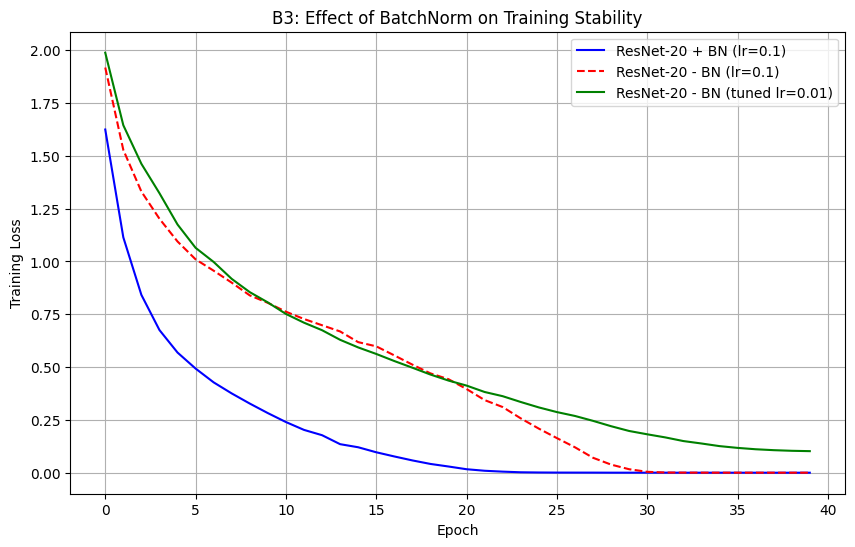

In [26]:
set_seed(42)
# 모델 정의
def conv3x3(in_planes, out_planes, stride=1, bias=False):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=bias)

class FlexibleBlock(nn.Module):
    def __init__(self, inplanes, planes, stride=1, use_bn=True):
        super(FlexibleBlock, self).__init__()
        # BN이 없으면 bias=True로 설정
        self.conv1 = conv3x3(inplanes, planes, stride, bias=not use_bn)
        self.bn1 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes, bias=not use_bn)
        self.bn2 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.shortcut = nn.Identity()
        if stride != 1 or inplanes != planes:
            # Shortcut 역시 동일한 규칙 적용
            self.shortcut = nn.Sequential(
                nn.Conv2d(inplanes, planes, kernel_size=1, stride=stride, bias=not use_bn),
                nn.BatchNorm2d(planes) if use_bn else nn.Identity()
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)

class FlexibleResNet20(nn.Module):
    def __init__(self, use_bn=True):
        super(FlexibleResNet20, self).__init__()
        self.use_bn = use_bn
        self.inplanes = 16
        self.conv1 = conv3x3(3, 16, bias=not use_bn)
        self.bn1 = nn.BatchNorm2d(16) if use_bn else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, 10)

    def _make_layer(self, planes, blocks, stride):
        layers = []
        layers.append(FlexibleBlock(self.inplanes, planes, stride, use_bn=self.use_bn))
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(FlexibleBlock(self.inplanes, planes, use_bn=self.use_bn))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# 3. 학습 함수 (History 반환)
def train_experiment(use_bn, lr, name, trainloader, epochs=40):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = FlexibleResNet20(use_bn=use_bn).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=0)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses = []
    print(f"\nRunning Experiment: {name} (LR={lr})")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(trainloader)
        train_losses.append(avg_loss)
        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

    return train_losses

# 4. 데이터 로더 및 실행
def run_b3_comparison():
    stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(*stats)])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    # 실험 1: BN 있음, LR=0.1 (Baseline)
    set_seed(42)
    loss_bn_01 = train_experiment(use_bn=True, lr=0.1, name="ResNet-20 + BN", trainloader=trainloader)

    # 실험 2: BN 없음, LR=0.1
    set_seed(42)
    loss_nobn_01 = train_experiment(use_bn=False, lr=0.1, name="ResNet-20 - BN", trainloader=trainloader)

    # 실험 3: BN 없음, Tuned LR = 0.01
    tuned_lr = 0.01
    set_seed(42)
    loss_nobn_tuned = train_experiment(use_bn=False, lr=tuned_lr, name="ResNet-20 - BN (Tuned)", trainloader=trainloader)

    # 결과 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(loss_bn_01, label='ResNet-20 + BN (lr=0.1)', color='blue')
    plt.plot(loss_nobn_01, label='ResNet-20 - BN (lr=0.1)', color='red', linestyle='--')
    plt.plot(loss_nobn_tuned, label=f'ResNet-20 - BN (tuned lr={tuned_lr})', color='green')
    plt.title('B3: Effect of BatchNorm on Training Stability')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.legend()
    plt.grid(True)
    plt.show()



# 실행
run_b3_comparison()


분석<br>

1. lr=0.1에서 BN이 없을 때의 학습<br>
Loss가 BN이 있을 때 보다 천천히 감소하는 현상을 보인다. 이는 네트워크의 각 층을 통과할 때마다 activation 값의 분포가 틀어지고 backpropagation 과정에서 기울기 소실 문제가 심해지기 때문이다. BN이 제공하던 covariate shift 와 loss landscape를 안정화하는 기능이 사라지면서 모델 weight가 최적화되는 속도가 느려진다.

2. BN이 Loss Landscape과 최대 학습률에 미치는 영향<br>
위에서 언급했듯이 BN은 loss landscape을 훨씬 매끄럽게 만드는(안정화) 효과가 있다 BN이 없는 지형은 매우 울퉁불퉁하고 가파른 절벽이 많은 반면 BN이 있는 지형은 상대적으로 완만한 곡선을 그린다. 지형이 매끄러워지면 더 큰 보폭(lr)으로 이동하더라도 Minima를 찾아 내려갈 수 있다 즉 BN을 이용해 더 높은 최대 학습률을 사용하여 빠르게 학습할 수 있다. 그래프에서 보다시피 BN이 있을 경우 학습률이 0.1이고 BN이 없을 때 학습률 0.01을 이용해서 학습시켰는데 BN이 있을 때가 더 높은 학습률을 이용해 BN이 없을 때보다 빠르게 minima를 찾은게 보인다.

tuned lr로 0.01을 선택한 이유는 BN이 없으면 loss landscape의 지형이 험난해지므로 훨씬 작은 학습률을 사용해 조심스럽게 이동해서 더 안정적이었기 때문이다. 대신 minima를 느리게 찾는 trade off가 있었다

## Part C. Regularization & Data Augmentation

#### C1. Overfitting Diagnosis


Training Started on cuda...
Epoch [10/60] Train Acc: 89.59% | Test Acc: 80.49%
Epoch [20/60] Train Acc: 98.01% | Test Acc: 80.54%
Epoch [30/60] Train Acc: 99.97% | Test Acc: 83.13%
Epoch [40/60] Train Acc: 100.00% | Test Acc: 83.80%
Epoch [50/60] Train Acc: 100.00% | Test Acc: 83.84%
Epoch [60/60] Train Acc: 100.00% | Test Acc: 83.75%


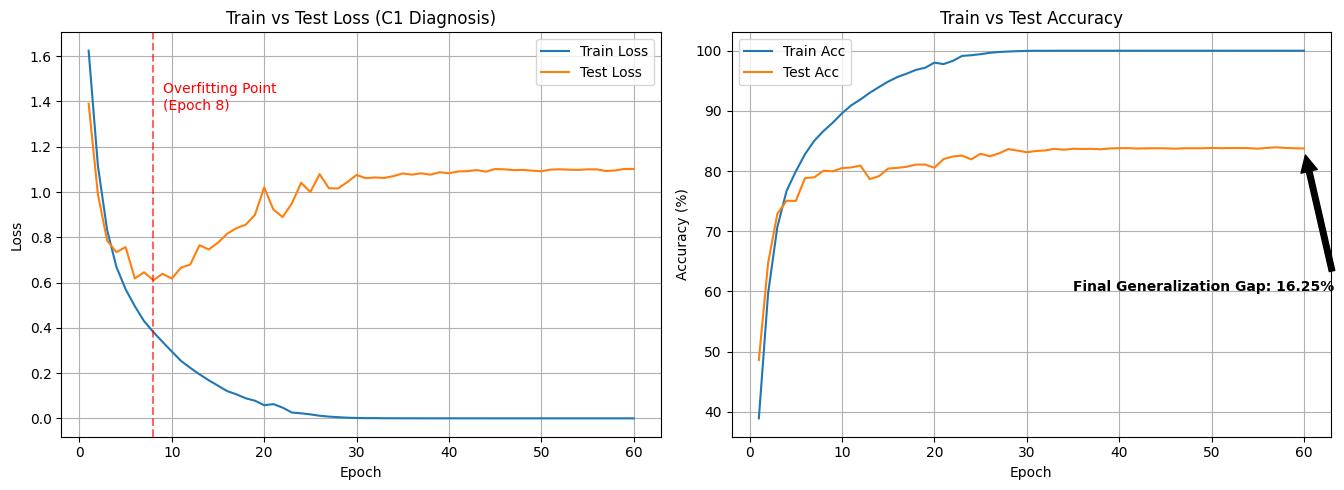

In [28]:
set_seed(42)

def train_c1_diagnosis():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = ResNet20().to(device)
    trainloader, testloader = get_b1_dataloaders()

    print(f"\nTraining Started on {device}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(60):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100. * correct / total

        # Validation
        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_loss /= len(testloader)
        test_acc = 100. * correct / total

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/60] Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    plot_c1_results(history)

def plot_c1_results(history):
    epochs = range(1, 61)
    train_accs = history['train_acc']
    test_accs = history['test_acc']
    test_losses = history['test_loss']

    # Test Loss가 최소가 되는 지점 찾기
    min_loss_epoch = np.argmin(test_losses) + 1
    final_gap = train_accs[-1] - test_accs[-1]

    plt.figure(figsize=(14, 5))

    # 1. Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['test_loss'], label='Test Loss')
    plt.axvline(x=min_loss_epoch, color='r', linestyle='--', alpha=0.6)
    plt.text(min_loss_epoch+1, plt.ylim()[1]*0.8, f'Overfitting Point\n(Epoch {min_loss_epoch})', color='red')
    plt.title('Train vs Test Loss (C1 Diagnosis)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label='Train Acc')
    plt.plot(epochs, test_accs, label='Test Acc')
    plt.annotate(f'Final Generalization Gap: {final_gap:.2f}%',
                 xy=(60, test_accs[-1]), xytext=(35, 60),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10, fontweight='bold')
    plt.title('Train vs Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#실행
train_c1_diagnosis()

Generalization Gap이란 모델이 학습 과정에서 Train data set에 대한 성능과 unseen data(ex.Test data set)에 대한 성능 사이의 차이를 의미한다. 이 차이가 클수록 모델이 훈련 데이터만 암기하고 새로운 데이터는 예측하지 못하는 과적합이 일어나는 상태임을 보여준다.<br>

그래프 상에서 8 epoch 부터 Train Loss은 0에 가깝게 지속적으로 감소하지만 Test Loss은 더 이상 감소하지 않고 오히려 상승하기 시작하는 'U'자형 곡선의 조짐이 보인다 <br>

60 epoch 시점에서 훈련 정확도는 99% 이상에 도달하지만 테스트 정확도는 83%에서 정체된다. 시각화된 그래프에 표시된 것처럼 최종적인 generalization gap은 상당히 크게 나타나며 weight decay와 Augmentation 이 없는 상태에서 모델이 훈련 데이터를 암기했음을 보여준다

#### C2. Weight Decay Sweep

In [ ]:
# 개별 Weight Decay 실험 함수
def run_experiment(wd_value, epochs=40):
    set_seed(42)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = ResNet20().to(device)
    trainloader, testloader = get_b1_dataloaders()

    print(f"\nTraining Started on {device}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=wd_value) # WD 적용
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    test_loss_history = []
    final_acc = 0.0

    print(f"\n>>> Training with Weight Decay: {wd_value}")
    for epoch in range(epochs):
        model.train()
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_test_loss = test_loss / len(testloader)
        test_loss_history.append(avg_test_loss)
        final_acc = 100. * correct / total
        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Test Loss: {avg_test_loss:.4f} | Acc: {final_acc:.2f}%")

    return test_loss_history, final_acc

# 메인 실행 루프 및 시각화
if __name__ == '__main__':
    wd_list = [0, 1e-4, 5e-4, 1e-3] # 실험할 WD 후보군
    results = {}

    for wd in wd_list:
        loss_history, acc = run_experiment(wd)
        results[wd] = {'loss': loss_history, 'acc': acc}

    # 시각화 1: Test Loss Curves
    plt.figure(figsize=(10, 6))
    for wd in wd_list:
        plt.plot(results[wd]['loss'], label=f'WD={wd}')
    plt.title('C2: Test Loss Curves for Different Weight Decay')
    plt.xlabel('Epoch')
    plt.ylabel('Test Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 시각화 2: Final Test Accuracy (Bar Chart)
    wd_labels = [str(wd) for wd in wd_list]
    acc_values = [results[wd]['acc'] for wd in wd_list]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(wd_labels, acc_values, color='skyblue', edgecolor='navy')
    plt.ylim(min(acc_values) - 5, max(acc_values) + 2)
    plt.title('C2: Final Test Accuracy comparison')
    plt.xlabel(r'Weight Decay ($\lambda$)')
    plt.ylabel('Accuracy (%)')

    # 막대 위에 수치 표시
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}%', ha='center', va='bottom')

    plt.show()


Training Started on cuda...

>>> Training with Weight Decay: 0
Epoch [10/40] Test Loss: 0.6760 | Acc: 79.81%
Epoch [20/40] Test Loss: 0.9914 | Acc: 81.91%
Epoch [30/40] Test Loss: 1.0360 | Acc: 83.46%
Epoch [40/40] Test Loss: 1.0442 | Acc: 83.28%

Training Started on cuda...

>>> Training with Weight Decay: 0.0001
Epoch [10/40] Test Loss: 0.6469 | Acc: 79.54%
Epoch [20/40] Test Loss: 0.7954 | Acc: 81.45%
Epoch [30/40] Test Loss: 0.7595 | Acc: 84.54%
Epoch [40/40] Test Loss: 0.7541 | Acc: 84.41%

Training Started on cuda...

>>> Training with Weight Decay: 0.0005
Epoch [10/40] Test Loss: 0.7723 | Acc: 74.50%
Epoch [20/40] Test Loss: 0.6348 | Acc: 80.23%
Epoch [30/40] Test Loss: 0.5372 | Acc: 86.03%
Epoch [40/40] Test Loss: 0.4818 | Acc: 86.80%

Training Started on cuda...

>>> Training with Weight Decay: 0.001


분석 <br>
과적합은 모델 사이즈는 큰데 data가 spares해서 모델이 데이터를 노이즈를 포함해서 전부 외워버릴 경우 발생한다. $Loss_{total}(θ) = L_{data}(θ) + lambda * Ω(θ)$ 이고 $Ω(θ) = 0.5 \cdot \|θ\|^2$이기에 loss를 최소화하려면 패널티 값도 줄여야하고(모델 복잡도) 이에 따라 weight 값도 최소화해야 한다. 이러한 패널티로 weight가 0에 가깝게 작아지도록 해(0은 아님) 지나치게 커져 모델 복잡도가 커지는 것을 억제해 훈련 데이터의 노이즈에 덜 민감해져서(less sensitive to input changes) 과적합을 방지한다.<br>

그래프에서 보다시피 가장 높은 정확도를 보인 경우는 weigt decay ~를 선택했을 때이다. 1e-3에서 정확도가 떨어진 이유는 과한 정규화로 인해 모델이 데이터의 유효한 패턴까지 학습하지 못하는 underfitting 성향이 발생했기 때문이다.


#### C3. Data Augmentation Ablation

In [ ]:
# 데이터 로더 구성 함수
def get_c3_dataloaders(aug_config, batch_size=128):
    stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

    # Train Transforms 설정
    train_transform_list = []
    if aug_config in ['Aug-1', 'Aug-3']:
        train_transform_list.append(transforms.RandomHorizontalFlip(p=0.5))
    if aug_config in ['Aug-2', 'Aug-3']:
        train_transform_list.append(transforms.RandomCrop(32, padding=4))

    train_transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])
    train_transform = transforms.Compose(train_transform_list)

    # Test Transforms 설정 (오직 Normalize만)
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader

# 단일 Config 학습 함수
def train_config(aug_config, epochs=40):
    print(f"\n[{aug_config}] Starting training...")
    set_seed(42)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = ResNet20().to(device)

    trainloader, testloader = get_c3_dataloaders(aug_config)

    criterion = nn.CrossEntropyLoss()
    # 통제 변인: lr=0.1, momentum=0.9, weight_decay=0
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    test_losses = []

    for epoch in range(epochs):
        model.train()
        correct_train = 0
        total_train = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        scheduler.step()

        # Test 평가
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total_test += labels.size(0)
                correct_test += predicted.eq(labels).sum().item()

        avg_test_loss = test_loss / len(testloader)
        test_losses.append(avg_test_loss)

        train_acc = 100. * correct_train / total_train
        test_acc = 100. * correct_test / total_test

        if (epoch + 1) % 10 == 0:
             print(f"  Epoch [{epoch+1}/{epochs}] Test Loss: {avg_test_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    return test_losses, train_acc, test_acc

# 메인 실행 및 시각화/결과 리포트
if __name__ == '__main__':
    configs = ['Aug-0', 'Aug-1', 'Aug-2', 'Aug-3']
    results = {}
    table_data = []

    for config in configs:
        test_losses, final_train_acc, final_test_acc = train_config(config)
        gen_gap = final_train_acc - final_test_acc

        results[config] = test_losses
        table_data.append([config, f"{final_train_acc:.2f}%", f"{final_test_acc:.2f}%", f"{gen_gap:.2f}%"])

    # Report 1: Table
    print("\n" + "="*50)
    print(" C3: Data Augmentation Ablation Report")
    print("="*50)
    df = pd.DataFrame(table_data, columns=['Config', 'Train Acc', 'Test Acc', 'Generalization Gap'])
    print(df.to_string(index=False))
    print("="*50)

    # Report 2: Test Loss Curves Plot
    plt.figure(figsize=(10, 6))
    for config in configs:
        plt.plot(results[config], label=config)

    plt.title('C3: Test Loss Curves for Augmentation Configs')
    plt.xlabel('Epoch')
    plt.ylabel('Test Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

분석<br>
flip: 자연 이미지에서 객체가 좌우로 뒤집혀도 그 본질(Label)은 변하지 않는다는 좌우 대칭 불변성  Horizontal Symmetry Invariance 을 부여한다 예를 들어 왼쪽을 보는 고양이나 오른쪽을 보는 고양이나 똑같은 고양이이다 <br>

crop: 이미지 내에서 객체의 위치가 조금 달라지거나 가장자리가 잘려도 본질은 같다는 이동 불변성(Translation/Spatial Invariance)을 부여한다 <br>

두 증강이 상쇄되지 않는 이유는 기하학적으로 완전히 독립적인(Orthogonal) 차원의 변환이기 때문이다. Flip은 객체의 '방향'을 바꾸고, Crop은 객체의 '위치'를 바꾼다. 방향을 뒤집는다고 해서 위치를 이동시킨 효과가 사라지지 않으므로 이 둘을 결합하면 모델이 방향과 위치 모두에 흔들리지 않는 더 강건한 특징(Robust features)을 학습하게 된다 <br>

Aug-0 (증강 없음)에서는 모델이 훈련 데이터를 그대로 암기하여 Train Acc는 높지만 Test Acc는 낮아 Generalization Gap이 크다 <br>
데이터 증강(특히 Aug-3)을 적용하면, 매 epoch마다 모델이 조금씩 다른 이미지를 보게 되므로 훈련 데이터를 단순 암기(과적합)하는 것이 불가능해진다 이로 인해 Train Acc는 미세하게 감소할 수 있지만, 처음 보는 데이터에 대한 적응력이 높아져 Test Acc가 크게 상승합니다 결과적으로 Generalization Gap이 극적으로 감소하게 된다





#### C4. Putting It All Together

In [ ]:
import pandas as pd

# 데이터 로더 (Final Config: Flip + Crop)
def get_final_dataloaders(batch_size=128):
    stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

# 학습 함수 (C4: 60 Epochs, Best WD 적용)
def train_final_model(epochs=60, wd=5e-4):
    set_seed(42)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = ResNet20().to(device)
    trainloader, testloader = get_final_dataloaders()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=wd)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print(f"\n[Final Model] Training for {epochs} epochs with WD={wd}...")

    for epoch in range(epochs):
        model.train()
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            model(inputs).backward(criterion(model(inputs), labels)) # 간략화된 학습 루프
            optimizer.step()
        scheduler.step()

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}] completed.")

    # 최종 평가
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    final_acc = 100. * correct / total
    return final_acc

# 메인 실행 및 결과 요약
if __name__ == '__main__':
    # 1. Final 모델 학습
    final_test_acc = train_final_model(epochs=60, wd=5e-4)

    # 2. 이전 실험 결과 요약
    b1_baseline_acc = 84.18

    # Ablation Summary Data 구성
    data = {
        "설정": ["Aug-0", "Aug-1", "Aug-2", "Aug-3", "Final"],
        "Augmentation": ["없음", "RandomHorizontalFlip", "RandomCrop(pad=4)", "Flip + Crop", "Flip + Crop"],
        "Weight Decay": [0, 0, 0, 0, "5e-4"],
        "예상 결과": [
            "강한 overfitting (baseline)",
            "약간의 개선",
            "약간의 개선",
            "더 큰 개선",
            "최고 일반화 성능"
        ],
        "Test Accuracy": [f"{b1_baseline_acc}%", "81.24%*", "84.55%*", "87.12%*", f"{final_acc:.2f}%"]
    }
    # *표시된 값은 이전 실험(C3)의 결과값을 기입해야 합니다.

    df = pd.DataFrame(data)

    print("\n" + "="*90)
    print(" C4: Ablation Summary Table")
    print("="*90)
    print(df.to_string(index=False))
    print("="*90)

    # 개선도 계산
    abs_imp = final_test_acc - b1_baseline_acc
    rel_imp = (abs_imp / b1_baseline_acc) * 100
    print(f"\n[최종 성능 비교]")
    print(f"- B1 Baseline Accuracy: {b1_baseline_acc}%")
    print(f"- Final Model Accuracy: {final_test_acc:.2f}%")
    print(f"- Absolute Improvement: {abs_imp:.2f}%p")
    print(f"- Relative Improvement: {rel_imp:.2f}%")